***

## Implement co-teaching

In this notebook, we will do the following:
* Load the data from CIFAR10 noisy dataset
* Create the model that has been mentioned in the paper
* Train it using co-teaching
* Get the loss values

***

In [1]:
import torch
import numpy as np

# from google.colab import drive
import seaborn as sns

from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms
from torchvision import datasets, models
import optuna

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torchvision


In [2]:
sns.set_style(style="darkgrid")

In [3]:
# for CIFAR 10
cifar_10_mean = [0.4914, 0.4822, 0.4465]
cifar_10_std = [0.2470, 0.2435, 0.2616]

# for CIFAR 100
cifar_100_mean = [0.5071, 0.4867, 0.4408]
cifar_100_std = [0.2675, 0.2565, 0.2761]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.RandomCrop((224,224)),
    # transforms.RandomHorizontalFlip(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root="./noise_rate_0.2_cifar10_images/train",
                                     transform=train_transform)

test_dataset = datasets.ImageFolder(root="./noise_rate_0.2_cifar10_images/test",
                                     transform=test_transform)

NOISE_RATE = 0.2
DATASET = 'CIFAR10'

# test_dataset = datasets.ImageFolder(root="./noise_rate_0.2_cifar10_images/test")

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=64,
                              shuffle=True,
                              num_workers=8,
                              persistent_workers=True
                              )


test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=64,
                              shuffle=False,
                              num_workers=8,
                              persistent_workers=True
                              )




In [4]:
train_dataloader

In [5]:
# validating the image and labels shape
for images, labels in train_dataloader:
  print(images.shape)
  print(labels.shape)
  break

torch.Size([64, 3, 224, 224])
torch.Size([64])


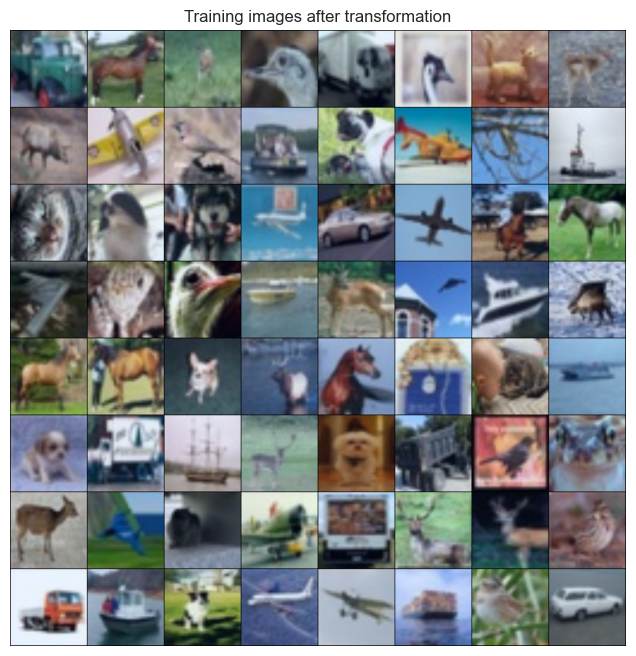

In [6]:
for images, labels in train_dataloader:
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images after transformation")
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64],
    padding=2,
    normalize=True),
    (1, 2, 0)))
plt.show()

In [7]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS is available. Using:", device)
else:
    device = torch.device("cpu")
    print("MPS not available. Using CPU instead.")

MPS is available. Using: mps


***

Defining the model mentioned in the co-teaching paper

***

In [8]:
import math
import torch
import torch.nn as nn
import torch.nn.init as init 
import torch.nn.functional as F
import torch.optim as optim

In [9]:
def call_bn(bn, x):
    return bn(x)

class CNN(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn
        super(CNN, self).__init__()
        self.c1=nn.Conv2d(input_channel,128,kernel_size=3,stride=1, padding=1)
        self.c2=nn.Conv2d(128,128,kernel_size=3,stride=1, padding=1)
        self.c3=nn.Conv2d(128,128,kernel_size=3,stride=1, padding=1)
        self.c4=nn.Conv2d(128,256,kernel_size=3,stride=1, padding=1)
        self.c5=nn.Conv2d(256,256,kernel_size=3,stride=1, padding=1)
        self.c6=nn.Conv2d(256,256,kernel_size=3,stride=1, padding=1)
        self.c7=nn.Conv2d(256,512,kernel_size=3,stride=1, padding=0)
        self.c8=nn.Conv2d(512,256,kernel_size=3,stride=1, padding=0)
        self.c9=nn.Conv2d(256,128,kernel_size=3,stride=1, padding=0)
        self.l_c1=nn.Linear(128,n_outputs)
        self.bn1=nn.BatchNorm2d(128)
        self.bn2=nn.BatchNorm2d(128)
        self.bn3=nn.BatchNorm2d(128)
        self.bn4=nn.BatchNorm2d(256)
        self.bn5=nn.BatchNorm2d(256)
        self.bn6=nn.BatchNorm2d(256)
        self.bn7=nn.BatchNorm2d(512)
        self.bn8=nn.BatchNorm2d(256)
        self.bn9=nn.BatchNorm2d(128)

    def forward(self, x,):
        h=x
        h=self.c1(h)
        h=F.leaky_relu(call_bn(self.bn1, h), negative_slope=0.01)
        h=self.c2(h)
        h=F.leaky_relu(call_bn(self.bn2, h), negative_slope=0.01)
        h=self.c3(h)
        h=F.leaky_relu(call_bn(self.bn3, h), negative_slope=0.01)
        h=F.max_pool2d(h, kernel_size=2, stride=2)
        h=F.dropout2d(h, p=self.dropout_rate)

        h=self.c4(h)
        h=F.leaky_relu(call_bn(self.bn4, h), negative_slope=0.01)
        h=self.c5(h)
        h=F.leaky_relu(call_bn(self.bn5, h), negative_slope=0.01)
        h=self.c6(h)
        h=F.leaky_relu(call_bn(self.bn6, h), negative_slope=0.01)
        h=F.max_pool2d(h, kernel_size=2, stride=2)
        h=F.dropout2d(h, p=self.dropout_rate)

        h=self.c7(h)
        h=F.leaky_relu(call_bn(self.bn7, h), negative_slope=0.01)
        h=self.c8(h)
        h=F.leaky_relu(call_bn(self.bn8, h), negative_slope=0.01)
        h=self.c9(h)
        h=F.leaky_relu(call_bn(self.bn9, h), negative_slope=0.01)
        h=F.avg_pool2d(h, kernel_size=h.data.shape[2])

        h = h.view(h.size(0), h.size(1))
        logit=self.l_c1(h)
        if self.top_bn:
            logit=call_bn(self.bn_c1, logit)
        return logit

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNFast(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn

        # conv blocks
        self.c1 = nn.Conv2d(input_channel, 128, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.act1 = nn.LeakyReLU(0.01, inplace=True)

        self.c2 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.act2 = nn.LeakyReLU(0.01, inplace=True)

        self.c3 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.act3 = nn.LeakyReLU(0.01, inplace=True)

        self.c4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.act4 = nn.LeakyReLU(0.01, inplace=True)

        self.c5 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.act5 = nn.LeakyReLU(0.01, inplace=True)

        self.c6 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.act6 = nn.LeakyReLU(0.01, inplace=True)

        self.c7 = nn.Conv2d(256, 512, 3, padding=0)
        self.bn7 = nn.BatchNorm2d(512)
        self.act7 = nn.LeakyReLU(0.01, inplace=True)

        self.c8 = nn.Conv2d(512, 256, 3, padding=0)
        self.bn8 = nn.BatchNorm2d(256)
        self.act8 = nn.LeakyReLU(0.01, inplace=True)

        self.c9 = nn.Conv2d(256, 128, 3, padding=0)
        self.bn9 = nn.BatchNorm2d(128)
        self.act9 = nn.LeakyReLU(0.01, inplace=True)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, n_outputs)

    def forward(self, x):
        x = self.act1(self.bn1(self.c1(x)))
        x = self.act2(self.bn2(self.c2(x)))
        x = self.act3(self.bn3(self.c3(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act4(self.bn4(self.c4(x)))
        x = self.act5(self.bn5(self.c5(x)))
        x = self.act6(self.bn6(self.c6(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act7(self.bn7(self.c7(x)))
        x = self.act8(self.bn8(self.c8(x)))
        x = self.act9(self.bn9(self.c9(x)))

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_small(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn

        # conv blocks
        self.c1 = nn.Conv2d(input_channel, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.act1 = nn.LeakyReLU(0.01, inplace=True)

        self.c2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.act2 = nn.LeakyReLU(0.01, inplace=True)

        self.c3 = nn.Conv2d(64, 32, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.act3 = nn.LeakyReLU(0.01, inplace=True)

        self.c4 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        self.act4 = nn.LeakyReLU(0.01, inplace=True)

        self.c5 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(32)
        self.act5 = nn.LeakyReLU(0.01, inplace=True)

        # self.c6 = nn.Conv2d(256, 256, 3, padding=1)
        # self.bn6 = nn.BatchNorm2d(256)
        # self.act6 = nn.LeakyReLU(0.01, inplace=True)

        # self.c7 = nn.Conv2d(256, 512, 3, padding=0)
        # self.bn7 = nn.BatchNorm2d(512)
        # self.act7 = nn.LeakyReLU(0.01, inplace=True)

        # self.c8 = nn.Conv2d(512, 256, 3, padding=0)
        # self.bn8 = nn.BatchNorm2d(256)
        # self.act8 = nn.LeakyReLU(0.01, inplace=True)

        # self.c9 = nn.Conv2d(256, 128, 3, padding=0)
        # self.bn9 = nn.BatchNorm2d(128)
        # self.act9 = nn.LeakyReLU(0.01, inplace=True)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, n_outputs)

    def forward(self, x):
        x = self.act1(self.bn1(self.c1(x)))
        x = self.act2(self.bn2(self.c2(x)))
        x = self.act3(self.bn3(self.c3(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act4(self.bn4(self.c4(x)))
        x = self.act5(self.bn5(self.c5(x)))
        # x = self.act6(self.bn6(self.c6(x)))
        # x = F.max_pool2d(x, 2, 2)
        # x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        # x = self.act7(self.bn7(self.c7(x)))
        # x = self.act8(self.bn8(self.c8(x)))
        # x = self.act9(self.bn9(self.c9(x)))

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [12]:
# co-teaching loss

import torch
import torch.nn.functional as F

# ignoring noise_or_not for now
def loss_coteaching_safe(y1, y2, t, forget_rate, ind, noise_or_not=None):
    """
    y1, y2: torch tensors (batch_size, num_classes) on device
    t: torch.LongTensor (batch_size,)
    forget_rate: float between 0 and 1
    ind: 1D tensor or numpy array of global indices for this batch (length batch_size)
    noise_or_not: 1D array/tensor indicating clean=1/noisy=0 indexed by global idx
    """
    device = y1.device
    # per-sample losses
    loss1 = F.cross_entropy(y1, t, reduction='none')  
    loss2 = F.cross_entropy(y2, t, reduction='none')

    # argsort ascending (small to large)
    ind1_sorted = torch.argsort(loss1)  
    ind2_sorted = torch.argsort(loss2)

    remember_rate = 1.0 - float(forget_rate)
    num_remember = int(remember_rate * loss1.shape[0])
    if num_remember <= 0:
        # Nothing to remember: return zero losses and zero purity
        zero = torch.tensor(0.0, device=device)
        return zero, zero, 0.0, 0.0

    ind1_update = ind1_sorted[:num_remember]
    ind2_update = ind2_sorted[:num_remember]

    # compute pure ratios (convert to numpy or torch consistently)
    # ensure ind is a numpy array or torch tensor on cpu for indexing noise_or_not if noise_or_not is numpy
    # if isinstance(noise_or_not, torch.Tensor):
    #     # assume noise_or_not is global tensor on same device or cpu
    #     # ind may be torch tensor with global indices
    #     nr = noise_or_not
    #     idx1 = ind[ind1_update].to(nr.device)
    #     idx2 = ind[ind2_update].to(nr.device)
    #     pure_ratio_1 = float(nr[idx1].sum().item()) / num_remember
    #     pure_ratio_2 = float(nr[idx2].sum().item()) / num_remember
    # else:
    #     # noise_or_not is numpy array
    #     ind_np = ind.cpu().numpy() if isinstance(ind, torch.Tensor) else ind
    #     sel1 = ind_np[ind1_update.cpu().numpy()]
    #     sel2 = ind_np[ind2_update.cpu().numpy()]
    #     pure_ratio_1 = float(noise_or_not[sel1].sum()) / num_remember
    #     pure_ratio_2 = float(noise_or_not[sel2].sum()) / num_remember

    # cross-update losses
    loss1_update = F.cross_entropy(y1[ind2_update], t[ind2_update], reduction='mean')
    loss2_update = F.cross_entropy(y2[ind1_update], t[ind1_update], reduction='mean')

    return loss1_update, loss2_update, 0, 0 #pure_ratio_1, pure_ratio_2


In [13]:
def evaluate_test_set(test_dataloader, model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_dataloader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    model.train()  # restore train mode as it does not happen automatically
    return correct / total if total > 0 else 0.0


In [14]:
# model training loop

def model_training_loop(train_dataloader,
                        test_dataloader,
                        noise_rate):
    torch.manual_seed(1)

    learning_rate = 0.01
    NUM_EPOCHS = 30
    train_accuracy_1_dict = {}
    train_loss_1_dict = {}
    train_accuracy_2_dict = {}
    train_loss_2_dict = {}

    test_accuracy_1_dict = {}
    test_accuracy_2_dict = {}
    

    # get the rate scheduler which decides how many samples to remember and to forget
    # the code below does the following
    # gradually increase the fraction of noisy samples for the first N epochs and then keep it constant
    # num_gradual: how many epochs for linear drop rate, can be 5, 10, 15. This parameter is equal to Tk for R(T) in Co-teaching paper.
    
    num_gradual = 10 # keeping it 2 because we are executing for only 10 epochs
    exponent = 1
    rate_schedule = np.ones(NUM_EPOCHS)*noise_rate
    rate_schedule[:num_gradual] = np.linspace(0, noise_rate**exponent, num_gradual)

    # init CNN_1
    # init CNN_2
    # cnn_1 = CNNFast().train()
    cnn_1 = CNN_small().train()
    cnn_1.to(device)
    optimizer_1 = torch.optim.Adam(cnn_1.parameters(), lr=learning_rate)
    
    # cnn_2 = CNNFast().train()
    cnn_2 = CNN_small().train()
    cnn_2.to(device)
    optimizer_2 = torch.optim.Adam(cnn_2.parameters(), lr=learning_rate)
    
    # run it for certain number of epochs
    for epoch in range(NUM_EPOCHS):
        # for accuracy calculation
        train_correct_1 = 0
        train_correct_2 = 0
        train_total_1 = 0

        for batch_idx, (features, labels) in enumerate(train_dataloader):
            
            features = features.to(device)
            labels = labels.to(device)


            # get predictions
            # with torch.no_grad():
            model_1_predictions_logits = cnn_1(features)
            model_2_predictions_logits = cnn_2(features)

            model_1_prediction = torch.argmax(model_1_predictions_logits, dim=1)
            model_2_prediction = torch.argmax(model_2_predictions_logits, dim=1)
            # print(model_1_prediction, model_2_prediction)
            
            train_correct_1 += (model_1_prediction == labels).sum().item()
            train_correct_2 += (model_2_prediction == labels).sum().item()
            
            train_total_1 += labels.size(0)

            # get the loss from CNN1
            # get the loss from CNN2
            loss_1, loss_2, _, _ = loss_coteaching_safe(y1=model_1_predictions_logits,
                                                        y2=model_2_predictions_logits,
                                                        t=labels,
                                                        forget_rate=rate_schedule[epoch], # keeping a fixed forget rate for now
                                                        ind=None, # excluding indices for now
                                                        noise_or_not=None
                                                        )
            # pass the losses to cross update co-teaching function
            optimizer_1.zero_grad()
            loss_1.backward()
            optimizer_1.step()

            optimizer_2.zero_grad()
            loss_2.backward()
            optimizer_2.step()

            

            # based on the losses do backward pass
            # update the optimizers
            if batch_idx % 100 == 0:
                print(f"Epoch: {epoch+1:03d}/{NUM_EPOCHS:03d}"
                    f" | Batch {batch_idx:03d}/{len(train_dataloader):03d}"
                    f" | Train Loss for CNN 1: {loss_1:.4f}"
                    f" | Train Loss for CNN 2: {loss_2:.4f}")

        train_loss_1_dict[epoch] = loss_1
        train_loss_2_dict[epoch] = loss_2

        # get the accuracy on train set
        train_accuracy_1 = float(train_correct_1) / float(train_total_1)
        train_accuracy_2 = float(train_correct_2) / float(train_total_1)
        train_accuracy_1_dict[epoch] = train_accuracy_1
        train_accuracy_2_dict[epoch] = train_accuracy_2

        # test set evaluation
        if test_dataloader is not None:
            test_accuracy_1 = evaluate_test_set(test_dataloader, cnn_1)
            test_accuracy_2 = evaluate_test_set(test_dataloader, cnn_2)
            test_accuracy_1_dict[epoch] = test_accuracy_1
            test_accuracy_2_dict[epoch] = test_accuracy_2

            # if epoch % 10 == 0:
            print(f"Epoch: {epoch+1:03d}/{NUM_EPOCHS:03d}"
                f" | TestAcc1: {test_accuracy_1:.4f}, TestAcc2: {test_accuracy_2:.4f}")

            
        torch.save({"epoch": epoch,
              "model_state_dict": cnn_1.state_dict(),
              "optimizer_state_dict": optimizer_1.state_dict(),
              "train_loss_1": train_loss_1_dict[epoch],
              "train_loss_2": train_loss_2_dict[epoch],
              "train_accuracy_1": train_accuracy_1_dict[epoch],
              "train_accuracy_2": train_accuracy_2_dict[epoch],
              "test_accuracy_1": test_accuracy_1_dict[epoch],
              "test_accuracy_2": test_accuracy_2_dict[epoch],
              },
             f'./model_output/co_teaching_{noise_rate}_{DATASET}_{epoch}.pth'
             )
        # get the accuracy on test set
        # store the results


In [15]:
model_training_loop(train_dataloader=train_dataloader,
                    test_dataloader=test_dataloader,
                    noise_rate=NOISE_RATE)

Epoch: 001/030 | Batch 000/782 | Train Loss for CNN 1: 2.3113 | Train Loss for CNN 2: 2.3825
Epoch: 001/030 | Batch 100/782 | Train Loss for CNN 1: 2.0555 | Train Loss for CNN 2: 2.0843
Epoch: 001/030 | Batch 200/782 | Train Loss for CNN 1: 2.0355 | Train Loss for CNN 2: 2.0359
Epoch: 001/030 | Batch 300/782 | Train Loss for CNN 1: 1.9558 | Train Loss for CNN 2: 2.0178
Epoch: 001/030 | Batch 400/782 | Train Loss for CNN 1: 1.9948 | Train Loss for CNN 2: 1.9549
Epoch: 001/030 | Batch 500/782 | Train Loss for CNN 1: 1.8251 | Train Loss for CNN 2: 1.8134
Epoch: 001/030 | Batch 600/782 | Train Loss for CNN 1: 1.9368 | Train Loss for CNN 2: 1.9446
Epoch: 001/030 | Batch 700/782 | Train Loss for CNN 1: 1.9321 | Train Loss for CNN 2: 1.9203
Epoch: 001/030 | TestAcc1: 0.2958, TestAcc2: 0.2822
Epoch: 002/030 | Batch 000/782 | Train Loss for CNN 1: 1.8604 | Train Loss for CNN 2: 1.9316
Epoch: 002/030 | Batch 100/782 | Train Loss for CNN 1: 1.7061 | Train Loss for CNN 2: 1.7803
Epoch: 002/030 | B